In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.svm import SVC
import pdb
import IPython
from math import exp

In [ ]:
# definiranje operacije
def f(x, a, b):
    return a * x + b

# definiranje varijabli i izgradnja dinamičnog
# računskog grafa s unaprijednim prolazom
a = torch.tensor(5., requires_grad=True)
b = torch.tensor(8., requires_grad=True)
x = torch.tensor(2.)
y = f(x, a, b)
s = a ** 2

# unatražni prolaz koji računa gradijent
# po svim tenzorima zadanim s requires_grad=True
y.backward()
s.backward()               # gradijent se akumulira
assert x.grad is None      # pytorch ne računa gradijente po x
assert a.grad == x + 2 * a # dy/da + ds/da
assert b.grad == 1         # dy/db + ds/db

# ispis rezultata
print(f"y={y}, g_a={a.grad}, g_b={b.grad}")
print(s)

y=18.0, g_a=12.0, g_b=1.0
tensor(25., grad_fn=<PowBackward0>)


In [ ]:
class Random2DGaussian:
  """Random bivariate normal distribution sampler

  Hardwired parameters:
      d0min,d0max: horizontal range for the mean
      d1min,d1max: vertical range for the mean
      scalecov: controls the covariance range

  Methods:
      __init__: creates a new distribution

      get_sample(n): samples n datapoints

  """

  d0min=0
  d0max=10
  d1min=0
  d1max=10
  scalecov=5

  def __init__(self):
    dw0,dw1 = self.d0max-self.d0min, self.d1max-self.d1min
    mean = (self.d0min,self.d1min)
    mean += np.random.random_sample(2)*(dw0, dw1)
    eigvals = np.random.random_sample(2)
    eigvals *= (dw0/self.scalecov, dw1/self.scalecov)
    eigvals **= 2
    theta = np.random.random_sample()*np.pi*2
    R = [[np.cos(theta), -np.sin(theta)],
         [np.sin(theta), np.cos(theta)]]
    Sigma = np.dot(np.dot(np.transpose(R), np.diag(eigvals)), R)
    self.get_sample = lambda n: np.random.multivariate_normal(mean,Sigma,n)


def graph_surface(function, rect, offset=0.5, width=256, height=256):
  """Creates a surface plot (visualize with plt.show)

  Arguments:
    function: surface to be plotted
    rect:     function domain provided as:
              ([x_min,y_min], [x_max,y_max])
    offset:   the level plotted as a contour plot

  Returns:
    None
  """

  lsw = np.linspace(rect[0][1], rect[1][1], width)
  lsh = np.linspace(rect[0][0], rect[1][0], height)
  xx0,xx1 = np.meshgrid(lsh, lsw)
  grid = np.stack((xx0.flatten(),xx1.flatten()), axis=1)

  #get the values and reshape them
  values=function(grid).reshape((width,height))

  # fix the range and offset
  delta = offset if offset else 0
  maxval=max(np.max(values)-delta, - (np.min(values)-delta))

  # draw the surface and the offset
  plt.pcolormesh(xx0, xx1, values,
     vmin=delta-maxval, vmax=delta+maxval)

  if offset != None:
    plt.contour(xx0, xx1, values, colors='black', levels=[offset])

def graph_data(X,Y_, Y, special=[]):
  """Creates a scatter plot (visualize with plt.show)

  Arguments:
      X:       datapoints
      Y_:      groundtruth classification indices
      Y:       predicted class indices
      special: use this to emphasize some points

  Returns:
      None
  """
  # colors of the datapoint markers
  palette=([0.5,0.5,0.5], [1,1,1], [0.2,0.2,0.2])
  colors = np.tile([0.0,0.0,0.0], (Y_.shape[0],1))
  for i in range(len(palette)):
    colors[Y_==i] = palette[i]

  # sizes of the datapoint markers
  sizes = np.repeat(20, len(Y_))
  sizes[special] = 40

  # draw the correctly classified datapoints
  good = (Y_==Y)
  plt.scatter(X[good,0],X[good,1], c=colors[good],
              s=sizes[good], marker='o', edgecolors='black')

  # draw the incorrectly classified datapoints
  bad = (Y_!=Y)
  plt.scatter(X[bad,0],X[bad,1], c=colors[bad],
              s=sizes[bad], marker='s', edgecolors='black')

def class_to_onehot(Y):
  Yoh=np.zeros((len(Y),max(Y)+1))
  Yoh[range(len(Y)),Y] = 1
  return Yoh

def eval_perf_binary(Y, Y_):
  tp = sum(np.logical_and(Y==Y_, Y_==True))
  fn = sum(np.logical_and(Y!=Y_, Y_==True))
  tn = sum(np.logical_and(Y==Y_, Y_==False))
  fp = sum(np.logical_and(Y!=Y_, Y_==False))
  recall = tp / (tp + fn)
  precision = tp / (tp + fp)
  accuracy = (tp + tn) / (tp+fn + tn+fp)
  return accuracy, recall, precision

def eval_perf_multi(Y, Y_):
  pr = []
  n = max(Y_)+1
  M = np.bincount(n * Y_ + Y, minlength=n*n).reshape(n, n)
  for i in range(n):
    tp_i = M[i,i]
    fn_i = np.sum(M[i,:]) - tp_i
    fp_i = np.sum(M[:,i]) - tp_i
    tn_i = np.sum(M) - fp_i - fn_i - tp_i
    recall_i = tp_i / (tp_i + fn_i)
    precision_i = tp_i / (tp_i + fp_i)
    pr.append( (recall_i, precision_i) )

  accuracy = np.trace(M)/np.sum(M)

  return accuracy, pr, M


def eval_AP(ranked_labels):
  """Recovers AP from ranked labels"""

  n = len(ranked_labels)
  pos = sum(ranked_labels)
  neg = n - pos

  tp = pos
  tn = 0
  fn = 0
  fp = neg

  sumprec=0
  #IPython.embed()
  for x in ranked_labels:
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)

    if x:
      sumprec += precision

    #print (x, tp,tn,fp,fn, precision, recall, sumprec)
    #IPython.embed()

    tp -= x
    fn += x
    fp -= not x
    tn += not x

  return sumprec/pos

def sample_gauss_2d(nclasses, nsamples):
  # create the distributions and groundtruth labels
  Gs=[]
  Ys=[]
  for i in range(nclasses):
    Gs.append(Random2DGaussian())
    Ys.append(i)

  # sample the dataset
  X = np.vstack([G.get_sample(nsamples) for G in Gs])
  Y_= np.hstack([[Y]*nsamples for Y in Ys])

  return X,Y_

def sample_gmm_2d(ncomponents, nclasses, nsamples):
  # create the distributions and groundtruth labels
  Gs=[]
  Ys=[]
  for i in range(ncomponents):
    Gs.append(Random2DGaussian())
    Ys.append(np.random.randint(nclasses))

  # sample the dataset
  X = np.vstack([G.get_sample(nsamples) for G in Gs])
  Y_= np.hstack([[Y]*nsamples for Y in Ys])

  return X,Y_

def myDummyDecision(X):
  scores = X[:,0] + X[:,1] - 5
  return scores

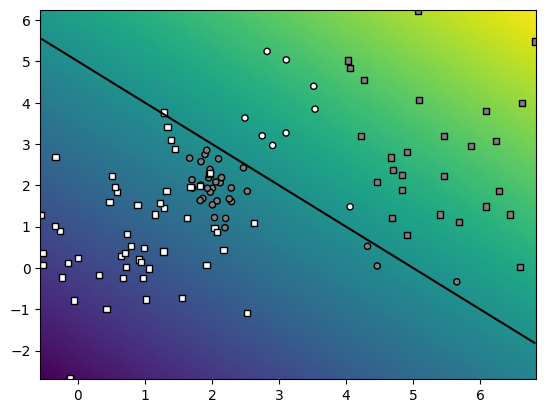

In [ ]:
np.random.seed(100)

  # get data
X,Y_ = sample_gmm_2d(4, 2, 30)
# X,Y_ = sample_gauss_2d(2, 100)

# get the class predictions
Y = myDummyDecision(X)>0.5

# graph the decision surface
rect=(np.min(X, axis=0), np.max(X, axis=0))
graph_surface(myDummyDecision, rect, offset=0)

# graph the data points
graph_data(X, Y_, Y, special=[])

plt.show()


Oblikujte i izvedite modul fcann2 za rad s probabilističkim klasifikacijskim modelom s jednim skrivenim slojem prema uputama iz odjeljka 0a. Neka organizacija vašeg koda bude sukladna organizaciji modula logreg iz prethodne vježbe. Napišite metode fcann2_train, fcann2_classify. Isprobajte njihov rad na umjetnom skupu 2D podataka dvaju razreda dobivenih iz Gaussove mješavine od 6 komponenata.

Ovisno o parametrima i stanju generatora slučajnih brojeva, vaš rezultat mogao bi izgledati kao na sljedećoj slici. Naši parametri bili su: K=6, C=2, N=10, param_niter=1e5, param_delta=0.05, param_lambda=1e-3 (koeficijent regularizacije), dimenzija skrivenog sloja: 5.



In [ ]:
class fcann2:
  def __init__(self, param_niter=1e5, param_delta=0.05, param_lambda=1e-3, dim_hidden=5):
    self.param_niter = int(param_niter)
    self.param_delta = param_delta
    self.param_lambda = param_lambda
    self.dim_hidden = dim_hidden

    self.W1 = None
    self.b1 = None
    self.W2 = None
    self.b2 = None

  @staticmethod
  def _stable_softmax(x): # shiftamo da izbjegnemo overflow eksponencijalne funkcije
    exp_x_shifted = np.exp(x - np.max(x, axis=1, keepdims=True))
    probs = exp_x_shifted / np.sum(exp_x_shifted, axis=1, keepdims=True)
    return probs

  @staticmethod
  def relu(x):
    return np.maximum(x, 0)


  def fcann2_train(self, X, Y):
    D = X.shape[1]
    C = max(Y)+1

    self.W1 = np.random.randn(D, self.dim_hidden) # distribucija oko 0
    self.b1 = np.zeros(self.dim_hidden)
    self.W2 = np.random.randn(self.dim_hidden, C)
    self.b2 = np.zeros(C)

    prev_loss = np.inf

    for i in range(self.param_niter):
      s1 = X @ self.W1 + self.b1 # (N,D) x (D,H) + (1,H) -> (N,H) + (1,H) -> (N,H)
      h1 = self.relu(s1)
      s2 = h1 @ self.W2 + self.b2 # (N,H) x (H,C) + (1,C) -> (N,C) + (1,C) -> (N,C)

      probs = self._stable_softmax(s2)

      loss = -np.mean(np.log(probs)[np.arange(X.shape[0]), Y])

      if i%1000 == 0:
        print(f"i: {i}, loss: {loss}")

      if abs(prev_loss - loss) < 0.000001:
        break
      prev_loss = loss

      dL_ds2 = (1/X.shape[0]) * (probs - np.identity(C)[Y]) # (N,C)
      grad_w2 = h1.T @ dL_ds2 + self.param_lambda * self.W2 # (H, N) x (N,C) + (H,C) -> (H,C)
      grad_b2 = np.sum(dL_ds2, axis=0)

      dl_dh1 = dL_ds2 @ self.W2.T # (N,C) x (C, H) -> (N,H)
      dl_ds1  = dl_dh1 * (s1 > 0).astype(float) # (N,H)
      grad_w1 = X.T @ dl_ds1 + self.param_lambda * self.W1 # (D,N) x (N,H) + (D,H) -> (D,H)
      grad_b1 = np.sum(dl_ds1, axis=0)

      self.W2 -= self.param_delta * grad_w2
      self.b2 -= self.param_delta * grad_b2
      self.W1 -= self.param_delta * grad_w1
      self.b1 -= self.param_delta * grad_b1

  def fcann2_classify(self, X): # obican forward pass
        s1 = X @ self.W1 + self.b1
        h1 = self.relu(s1)
        s2 = h1 @ self.W2 + self.b2
        probs = self._stable_softmax(s2)
        return np.argmax(probs, axis=1)

  def decision(self, X):
    s1 = X @ self.W1 + self.b1
    h1 = self.relu(s1)
    s2 = h1 @ self.W2 + self.b2
    probs = self._stable_softmax(s2)
    return probs[:,1]



In [ ]:
X, Y = sample_gmm_2d(6, 2, 10)

X = (X - np.mean(X, axis=0)) / np.std(X, axis=0) # izbjeljivanje

model = fcann2()
model.fcann2_train(X, Y)
Y_pred = model.fcann2_classify(X)

i: 0, loss: 0.995959989980395


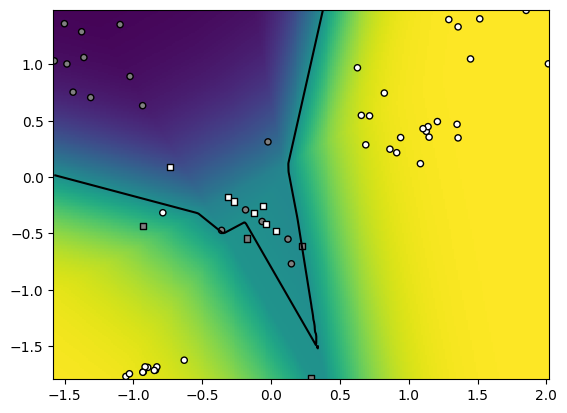

In [ ]:
rect = (np.min(X, axis=0), np.max(X, axis=0))
graph_surface(model.decision, rect, offset=0.5)
Y_pred = model.fcann2_classify(X)
graph_data(X, Y, Y_pred, special=[])
plt.show()

Linearna regresija u PyTorchu

Zadatci:
Ponovite osnove PyTorcha navedene u odjeljcima 0b i 0c. Analizirajte prikazani program te provjerite ispravnost izvođenja.
Modificirajte program na način da se pravac može provući kroz proizvoljan broj točaka. Pripazite da iznosi gradijenata budu neovisni o broju podataka.
Ispišite vrijednosti gradijenata tijekom napredovanja postupka.
Odredite analitičke izraze za gradijente funkcije gubitka po parametrima a i b. Izračunajte eksplicitno te gradijente. Ispišite vrijednosti gradijenata i uvjerite se da odgovaraju onima koje automatski određuje PyTorch.



In [ ]:
## Definicija računskog grafa
# podaci i parametri, inicijalizacija parametara
a = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

X = torch.tensor([1, 2])
Y = torch.tensor([3, 5])

# optimizacijski postupak: gradijentni spust
optimizer = optim.SGD([a, b], lr=0.1)

for i in range(100):
    # afin regresijski model
    Y_ = a*X + b

    diff = (Y-Y_)

    # kvadratni gubitak
    loss = torch.mean(diff**2)

    # računanje gradijenata
    loss.backward()

    print()
    print(a.grad.item(), b.grad.item())
    print(-2* torch.mean(diff*X), -2*torch.mean(diff))

    # korak optimizacije
    optimizer.step()

    # Postavljanje gradijenata na nulu
    optimizer.zero_grad()

    print(f'step: {i}, loss:{loss}, Y_:{Y_}, a:{a}, b {b}')


-4.062935829162598 -2.5565383434295654
tensor(-4.0629, grad_fn=<MulBackward0>) tensor(-2.5565, grad_fn=<MulBackward0>)
step: 0, loss:1.6860145330429077, Y_:tensor([1.9499, 3.4936], grad_fn=<AddBackward0>), a:tensor([1.9500], requires_grad=True), b tensor([0.6618], requires_grad=True)

-1.2645058631896973 -0.8263497352600098
tensor(-1.2645, grad_fn=<MulBackward0>) tensor(-0.8263, grad_fn=<MulBackward0>)
step: 1, loss:0.1713375449180603, Y_:tensor([2.6118, 4.5618], grad_fn=<AddBackward0>), a:tensor([2.0765], requires_grad=True), b tensor([0.7444], requires_grad=True)

-0.38434839248657227 -0.28172826766967773
tensor(-0.3843, grad_fn=<MulBackward0>) tensor(-0.2817, grad_fn=<MulBackward0>)
step: 2, loss:0.021305307745933533, Y_:tensor([2.8209, 4.8974], grad_fn=<AddBackward0>), a:tensor([2.1149], requires_grad=True), b tensor([0.7726], requires_grad=True)

-0.10765576362609863 -0.11007809638977051
tensor(-0.1077, grad_fn=<MulBackward0>) tensor(-0.1101, grad_fn=<MulBackward0>)
step: 3, loss

Logistička regresija u PyTorchu
U ovom zadatku ćemo postupak logističke regresije izvesti uz pomoć PyTorcha. Dobiveni kod će biti oko dvostruko kraći od "ručnog rada" koji je bio predmet nulte vježbe. Glavne prednosti PyTorcha su u tome što ne moramo izvoditi gradijente te što se dobiveni program bez ikakvih izmjena može izvršavati na moćnim grafičkim karticama. Te prednosti će se pokazati presudnima kod velikih modela sa stotinama milijuna slobodnih parametara (kod malih modela procesori opće namjene mogu biti brži od grafičkih procesora zbog dugotrajnog prebacivanja podataka).

U PyTorchu model obično izražavamo nasljeđivanjem osnovnog razreda torch.nn.Module. Pritom je potrebno definirati konstruktor i funkciju forward koja predstavlja unaprijedni prolaz kroz model. Tenzore koji predstavljaju parametre modela kao atribute tipa torch.nn.Parameter. To nam omogučava jednostavan pristup parametrima modela korištenjem funkcije torch.nn.Module.parameters(). Modul za učenje logističke regresije bi mogao izgledati ovako:

In [ ]:
class PTLogreg(nn.Module):
  def __init__(self, D, C, param_lambda=0.001):
    """Arguments:
       - D: dimensions of each datapoint
       - C: number of classes
    """
    super().__init__()
    self.W = nn.Parameter(torch.randn(D, C))
    self.b = torch.nn.Parameter(torch.zeros(C))
    self.param_lambda = param_lambda


  def forward(self, X):
    scores = torch.mm(X, self.W) + self.b
    scores = scores - torch.max(scores, dim=1, keepdim=True).values
    return torch.softmax(scores, dim=1)


  def get_loss(self, X, Yoh_):
    probs = self.forward(X)
    loss = -torch.mean(torch.sum(Yoh_ * torch.log(probs), dim=1))
    loss = loss + self.param_lambda * torch.sum(self.W ** 2)
    return loss


def train(model, X, Yoh_, param_niter, param_delta):
  """Arguments:
    - X: model inputs [NxD], type: torch.Tensor
    - Yoh_: ground truth [NxC], type: torch.Tensor
    - param_niter: number of training iterations
    - param_delta: learning rate
  """

  # inicijalizacija optimizatora
  optimizer = optim.SGD(model.parameters(), lr=param_delta)

  # petlja učenja
  # ispisujte gubitak tijekom učenja
  prev_loss = torch.inf

  for i in range(param_niter):
    optimizer.zero_grad()
    loss = model.get_loss(X, Yoh_)
    loss.backward()
    optimizer.step()

    if i % 100 == 0:
      print(f"i: {i}, loss: {loss.item()}")

    if abs(loss.item() - prev_loss) < 0.000001:
      break
    prev_loss = loss.item()


def eval(model, X):
  """Arguments:
    - model: type: PTLogreg
    - X: actual datapoints [NxD], type: np.array
    Returns: predicted class probabilites [NxC], type: np.array
  """
  # ulaz je potrebno pretvoriti u torch.Tensor
  # izlaze je potrebno pretvoriti u numpy.array
  # koristite torch.Tensor.detach() i torch.Tensor.numpy()
  X = torch.Tensor(X)
  probs = model.forward(X)
  return probs.detach().numpy()

In [ ]:
np.random.seed(100)
X, Y_ = sample_gmm_2d(6, 2, 10)
Yoh_ = class_to_onehot(Y_)
lr = PTLogreg(X.shape[1], Yoh_.shape[1])
train(lr, torch.tensor(X, dtype=torch.float32), torch.tensor(Yoh_,dtype=torch.float32), 10000, 0.075)
probs = eval(lr, X)
Y_pred = np.argmax(probs, axis=1)
a,p,m = eval_perf_multi(Y_, Y_pred)
print(a)
print(p)
print(m)


i: 0, loss: 1.0858708620071411
i: 100, loss: 0.6707316040992737
i: 200, loss: 0.6693405508995056
i: 300, loss: 0.6690528988838196
0.6
[(np.float64(0.6071428571428571), np.float64(0.5666666666666667)), (np.float64(0.59375), np.float64(0.6333333333333333))]
[[17 11]
 [13 19]]


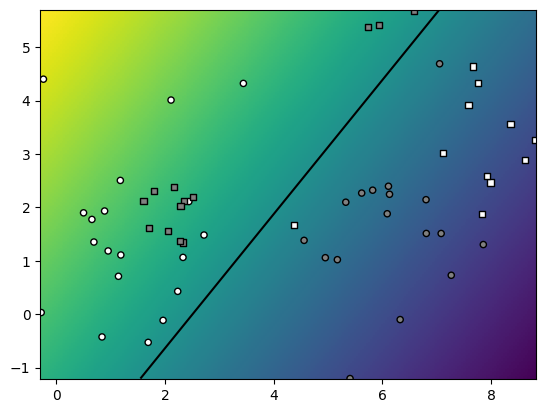

In [ ]:
rect = (np.min(X, axis=0), np.max(X, axis=0))
graph_surface(lambda x: eval(lr, x)[:, 1], rect)
graph_data(X, Y_, Y_pred)


Zadatci:

Izvedite razred PTDeep te isprobajte konfiguraciju [2, 3] na istim podatcima kao i u prethodnom zadatku (ispitni program će vam biti vrlo sličan). Provjerite da su rezultati isti kao i ranije.
Napišite metodu count_params koja će ispisati simboličko ime i dimenzije tenzora svih parametara. Dodatno, neka funkcija računa i ukupan broj parametara modela (npr. za konfiguraciju [2, 3] rezultat bi trebao biti 9). Za obilazak svih parametara modela sada elegantno možemo koristiti iterator named_parameters.
Isprobajte vaš kod na podatcima dobivenim pozivima data.sample_gmm_2d(4, 2, 40) i data.sample_gmm_2d(6, 2, 10), za konfiguracije [2, 2], [2, 10, 2] i [2, 10, 10, 2]. Ispišite točnost, odziv, preciznost i prosječnu preciznost te grafički prikažite rezultate klasifikacije i izgled decizijske plohe. Ako ne dođe do konvergencije, obratite pažnju na vrijednosti hiperparametara.
Usporedite rezultate s onim što se zbiva kad za prijenosnu funkciju postavite sigmoidu. Sigmoida bi za ovakve male probleme zbog neprekidnosti trebala postići bolje rezultate od zglobnice. Glavna prednost zglobnice je u tome što nema zasićenje pa kod dubljih modela gradijenti teže nestaju.
Ovisno o parametrima i stanju generatora slučajnih brojeva, vaš rezultat mogao bi izgledati kao na sljedećoj animaciji (naši parametri bili su: K=6, C=2, N=10, param_niter=1e4, param_delta=0.1, param_lambda=1e-4 (koeficijent regularizacije), config=[2, 10, 10, 2], ReLU).

In [ ]:
class PTDeep(nn.Module):
  def __init__(self, dims, param_lambda=0.0001):
    super().__init__()
    self.weights = nn.ParameterList()
    self.biases = nn.ParameterList()
    for dim_in, dim_out in zip(dims[:-1], dims[1:]):
        self.weights.append(nn.Parameter(torch.randn(dim_in, dim_out)))
        self.biases.append(nn.Parameter(torch.zeros(dim_out)))
    self.param_lambda = param_lambda


  def forward(self, X):
    for i, (W, b) in enumerate(zip(self.weights, self.biases)):
      X = torch.mm(X, W) + b
      if i < len(self.weights) - 1:
        X = torch.relu(X)
    return torch.log_softmax(X, dim=1)


  def get_loss(self, X, Yoh_):
    probs = self.forward(X)
    loss = -torch.mean(torch.sum(Yoh_ * probs, dim=1))
    loss = loss + self.param_lambda * sum(torch.sum(W ** 2) for W in self.weights)
    return loss


def train(model, X, Yoh_, param_niter, param_delta):
  optimizer = optim.SGD(model.parameters(), lr=param_delta)
  prev_loss = torch.inf
  for i in range(param_niter):
    optimizer.zero_grad()
    loss = model.get_loss(X, Yoh_)
    loss.backward()
    optimizer.step()

    if i % 1000 == 0:
      print(f"i: {i}, loss: {loss.item()}")

    if abs(loss.item() - prev_loss) < 0.000001:
      break
    prev_loss = loss.item()


def eval(model, X):
  X = torch.Tensor(X)
  log_probs = model.forward(X)
  probs = torch.exp(log_probs)
  return probs.detach().numpy()


In [ ]:
np.random.seed(100)
X, Y_ = sample_gmm_2d(6, 2, 10)
Yoh_ = class_to_onehot(Y_)
lr = PTDeep([2, 10, 10, 2])
train(lr, torch.tensor(X, dtype=torch.float32), torch.tensor(Yoh_,dtype=torch.float32), 10000, 0.1)
probs = eval(lr, X)
Y_pred = np.argmax(probs, axis=1)
a,p,m = eval_perf_multi(Y_, Y_pred)
print(a)
print(p)
print(m)


i: 0, loss: 35.38983917236328
i: 1000, loss: 0.5007302761077881
i: 2000, loss: 0.25871366262435913
0.7666666666666667
[(np.float64(0.6818181818181818), np.float64(1.0)), (np.float64(1.0), np.float64(0.5333333333333333))]
[[30 14]
 [ 0 16]]


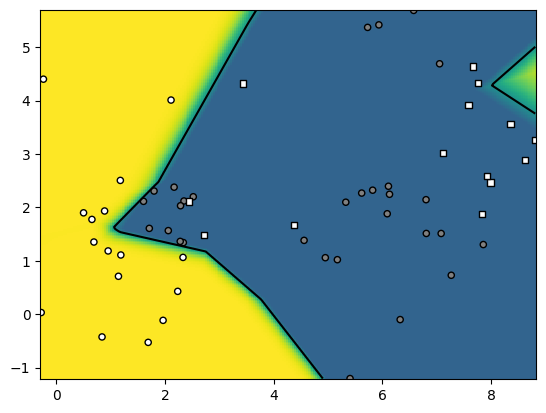

In [ ]:
rect = (np.min(X, axis=0), np.max(X, axis=0))
graph_surface(lambda x: eval(lr, x)[:, 1], rect)
graph_data(X, Y_, Y_pred)

In [ ]:
class KSVMWrap:
  def __init__(self, X, Y_, param_svm_c=1, param_svm_gamma="auto"):
    self.model = SVC(C=param_svm_c, gamma=param_svm_gamma, kernel="rbf")
    self.model.fit(X, Y_)

  def predict(self, X):
    return self.model.predict(X)

  def get_scores(self, X):
    return self.model.decision_function(X)

  def get_support(self):
    return self.model.support_


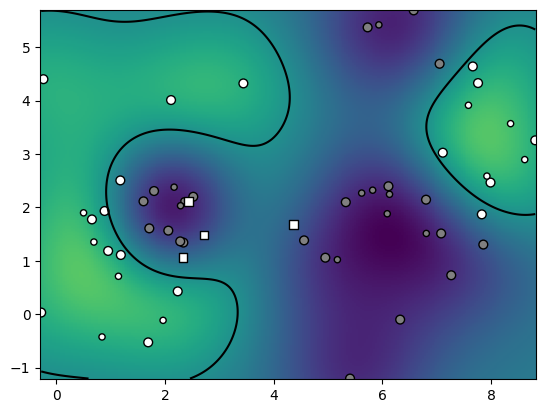

0.9333333333333333
[(np.float64(0.8823529411764706), np.float64(1.0)), (np.float64(1.0), np.float64(0.8666666666666667))]
[[30  4]
 [ 0 26]]


In [ ]:
np.random.seed(100)
X, Y_ = sample_gmm_2d(6, 2, 10)
model = KSVMWrap(X, Y_)
Y_pred = model.predict(X)

rect = (np.min(X, axis=0), np.max(X, axis=0))
graph_surface(model.get_scores, rect)
graph_data(X, Y_, Y_pred, special=model.get_support())
plt.show()
a,p,m = eval_perf_multi(Y_, Y_pred)
print(a)
print(p)
print(m)
